# Libraries

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
from sklearn.model_selection import train_test_split

import torchvision

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

from torchsummary import summary

/tmp/ipython-input-57994026.py:14: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

# Data

In [3]:
# download dataset
cdata = torchvision.datasets.EMNIST(root = 'emnist', split = 'letters', download = True)
cdata

100%|██████████| 562M/562M [00:37<00:00, 15.2MB/s]


Dataset EMNIST
    Number of datapoints: 124800
    Root location: emnist
    Split: Train

In [4]:
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
images = cdata.data.unsqueeze(1)
print('\nTensor data:')
print(images.shape)

['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# brief aside: class 'N/A' doesn't exist in the data.
print(torch.sum(cdata.targets == 0))

# However, it casuses problems in one-hot encoding
torch.unique(cdata.targets)

tensor(0)


tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

In [6]:
cdata.class_to_idx

{'N/A': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

## Labels

In [7]:
# therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letter_categories = cdata.classes[1:]

# relabel label to start at 0
labels = copy.deepcopy(cdata.targets)-1
print(labels.shape)

print(torch.sum(labels == 0))
torch.unique(labels)

torch.Size([124800])
tensor(4800)


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

## Norm

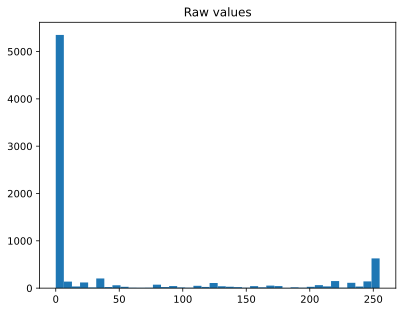

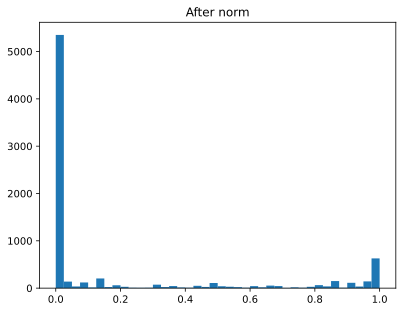

In [8]:
plt.hist(images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('Raw values')
plt.show()

images = images / torch.max(images)

plt.hist(images[:10,:,:,:].view(1,-1).detach()[0], 40)
plt.title('After norm')
plt.show()

## Viz

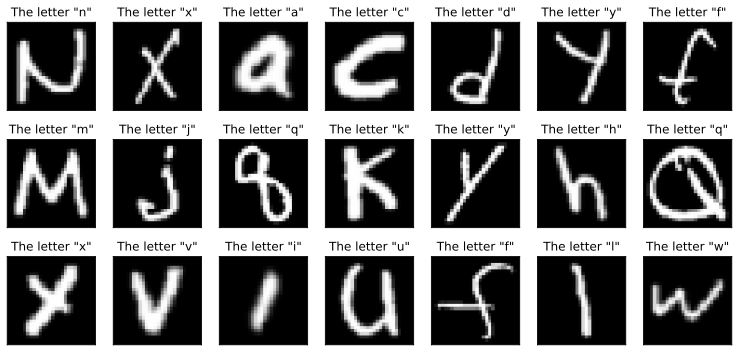

In [9]:
fig, axs = plt.subplots(3, 7, figsize = (13,6))

for i, ax in enumerate(axs.flatten()):

  # pick a random pic
  pic = np.random.randint(images.shape[0])

  # extract the image and its target letter
  I = np.squeeze(images[pic,:,:])
  letter = letter_categories[labels[pic]]

  # viz
  ax.imshow(I.T, cmap = 'gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Loaders

In [10]:
train_data, test_data, train_labels, test_labels = train_test_split(images, labels, test_size = .2)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = test_data.shape[0], shuffle = False)

In [11]:
# check size (should be images X channels X width X height)
print(train_dataloader.dataset.tensors[0].shape)
print(train_dataloader.dataset.tensors[1].shape)

torch.Size([99840, 1, 28, 28])
torch.Size([99840])


In [12]:
labels.unique()

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

# Model

In [13]:
def CreateModel(verbose):

  class CreateNet(nn.Module):
    def __init__(self):
      super().__init__()

      self.conv1 = nn.Conv2d(1, 6, 3, 1, 1)
      self.batchNorm1 = nn.BatchNorm2d(6)
      # (28 + 2 - 3) / 1 + 1 = 28
      # 28 // 2 = 14
      self.conv2 = nn.Conv2d(6, 4, 3, 1, 1)
      self.batchNorm2 = nn.BatchNorm2d(4)
      # (14 + 2 - 3) / 1 + 1 = 14
      # 14 // 2 = 7
      self.fc1 = nn.Linear(7*7*4, 50)
      self.fc2 = nn.Linear(50, 26)

    def forward(self, x):
      x = F.max_pool2d(self.conv1(x), 2)
      x = F.leaky_relu(self.batchNorm1(x))
      if verbose: print(f'First CPR block: {list(x.shape)}')

      x = F.max_pool2d(self.conv2(x), 2)
      x = F.leaky_relu(self.batchNorm2(x))
      if verbose: print(f'Second CPR block: {list(x.shape)}')

      # reshape for linear layer
      n_units = x.shape.numel()/x.shape[0]
      x = x.view(-1, int(n_units))
      if verbose: print(f'Vectorized: {list(x.shape)}')

      # linear layers
      x = F.leaky_relu(self.fc1(x))
      x = self.fc2(x)
      if verbose: print(f'Final output: {list(x.shape)}')

      return x

  net = CreateNet()
  optimizer = torch.optim.Adam(net.parameters(), lr = 1e-3)
  loss_fn = nn.CrossEntropyLoss()

  return net, loss_fn, optimizer

In [14]:
X, y = next(iter(train_dataloader))
net, loss_fn, optimizer = CreateModel(True)
y_hat = net(X)
loss = loss_fn(y_hat, y)
loss

First CPR block: [32, 6, 14, 14]
Second CPR block: [32, 4, 7, 7]
Vectorized: [32, 196]
Final output: [32, 26]


tensor(3.2827, grad_fn=<NllLossBackward0>)

In [22]:
summary(net.to(device), (1, 28, 28))

First CPR block: [2, 6, 14, 14]
Second CPR block: [2, 4, 7, 7]
Vectorized: [2, 196]
Final output: [2, 26]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]              60
       BatchNorm2d-2            [-1, 6, 14, 14]              12
            Conv2d-3            [-1, 4, 14, 14]             220
       BatchNorm2d-4              [-1, 4, 7, 7]               8
            Linear-5                   [-1, 50]           9,850
            Linear-6                   [-1, 26]           1,326
Total params: 11,476
Trainable params: 11,476
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.04
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


# Train

In [23]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [24]:
def RunModel(epochs, verbose):

  # create a new model
  net, loss_fn, optimizer = CreateModel(verbose)

  net = net.to(device)

  # initialize losses
  train_losses = torch.zeros(epochs)
  test_losses = torch.zeros(epochs)
  train_accs = torch.zeros(epochs)
  test_accs = torch.zeros(epochs)

  for epoch in range(epochs):
    # loop over training data batches
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      y_hat = net(X)
      loss = loss_fn(y_hat, y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # batch loss and acc
      preds = torch.argmax(y_hat, dim=1)
      batch_accs.append((preds == y).float().mean().item())
      batch_losses.append(loss.item())

    # losses
    train_accs[epoch] = 100 * np.mean(batch_accs)
    train_losses[epoch] = np.mean(batch_losses)

    # test acc
    X, y = next(iter(test_dataloader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad():
      y_hat = net(X)
      loss = loss_fn(y_hat, y)
      preds = torch.argmax(y_hat, dim=1)

    test_losses[epoch] = loss.item()
    test_accs[epoch] = 100 * (preds == y).float().mean().item()


    print(f'Epoch {epoch} Train Loss: {train_losses[epoch]:.4f}, Test Loss: {test_losses[epoch]:.4f}, Train Acc: {train_accs[epoch]:.4f}, Test Acc: {test_accs[epoch]:.4f}')

  return train_losses, test_losses, train_accs, test_accs, net

In [25]:
train_losses, test_losses, train_accs, test_accs, net = RunModel(epochs = 10, verbose = False)

Epoch 0 Train Loss: 0.6518, Test Loss: 0.3998, Train Acc: 80.4497, Test Acc: 87.2716
Epoch 1 Train Loss: 0.3663, Test Loss: 0.3385, Train Acc: 88.3373, Test Acc: 89.2668
Epoch 2 Train Loss: 0.3175, Test Loss: 0.3118, Train Acc: 89.8207, Test Acc: 90.0521
Epoch 3 Train Loss: 0.2933, Test Loss: 0.2867, Train Acc: 90.4848, Test Acc: 90.7652
Epoch 4 Train Loss: 0.2734, Test Loss: 0.2856, Train Acc: 91.0567, Test Acc: 90.8253
Epoch 5 Train Loss: 0.2612, Test Loss: 0.2791, Train Acc: 91.3502, Test Acc: 90.8654
Epoch 6 Train Loss: 0.2506, Test Loss: 0.2817, Train Acc: 91.6707, Test Acc: 90.8694
Epoch 7 Train Loss: 0.2433, Test Loss: 0.2679, Train Acc: 91.8710, Test Acc: 91.4463
Epoch 8 Train Loss: 0.2355, Test Loss: 0.2741, Train Acc: 92.1294, Test Acc: 91.1899
Epoch 9 Train Loss: 0.2294, Test Loss: 0.2696, Train Acc: 92.2626, Test Acc: 91.3141


# Plots

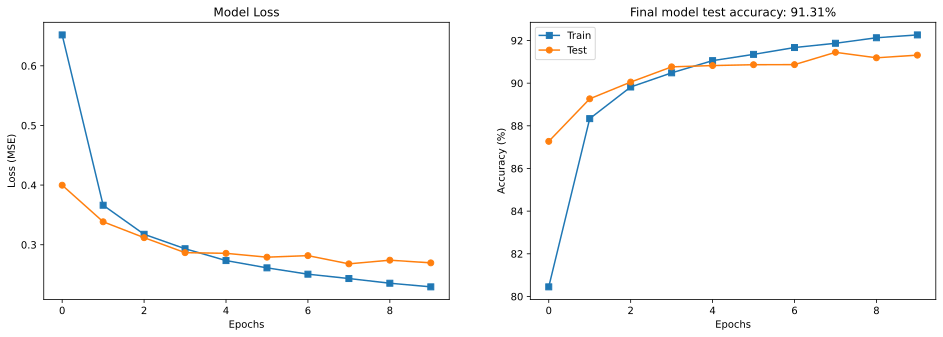

In [26]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_losses.cpu().detach(), 's-', label = 'Train')
ax[0].plot(test_losses.cpu().detach(), 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs.cpu().detach(), 's-', label = 'Train')
ax[1].plot(test_accs.cpu().detach(), 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

# Viz

## Err Letters

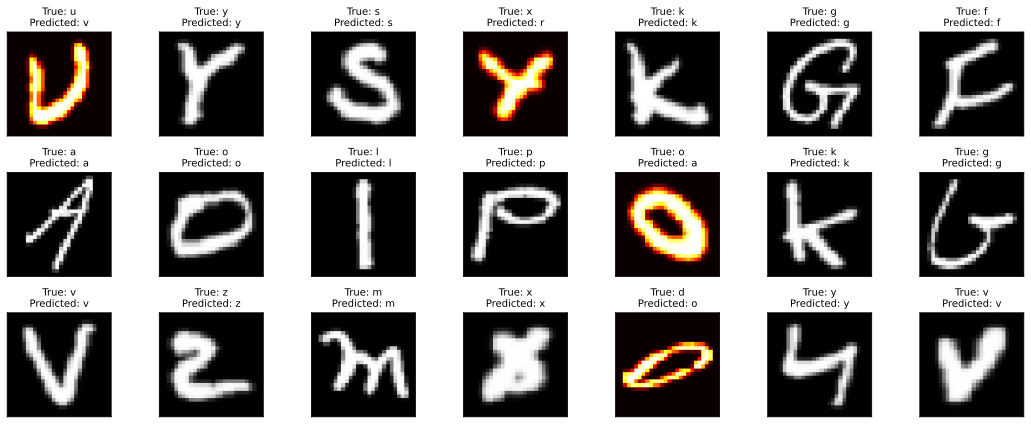

In [29]:
### visualize some images

# extract X,y from test_dataloader
X, y = next(iter(test_dataloader))
X = X.to(device)
y = y.to(device)

y_hat = net(X)

# random samples
rand_idx = np.random.choice(len(y), size = 21, replace = False)

# visualize some images
fig, axs = plt.subplots(3, 7, figsize = (15, 6))

for i, ax in enumerate(axs.flatten()):

  # extract the image and its target letter
  I = np.squeeze(X[rand_idx[i],0,:,:].cpu().detach())
  true_letter = letter_categories[y[rand_idx[i]]]
  pred_letter = letter_categories[torch.argmax(y_hat[rand_idx[i], :])]

  # color-code the accuracy (using ternary operator)
  col = 'gray' if true_letter == pred_letter else 'hot'

  # visualize
  ax.imshow(I.T, cmap = col)
  ax.set_title('True: %s\nPredicted: %s' %(true_letter, pred_letter), fontsize = 10)
  ax.set_xticks([])
  ax.set_yticks([])

plt.tight_layout()
plt.show()

## Accuracy by letter

In [39]:
y

tensor([17,  7, 23,  ...,  9,  1, 21], device='cuda:0')

In [40]:
torch.argmax(y_hat, axis = 1)

tensor([17, 20, 23,  ...,  9,  1, 21], device='cuda:0')

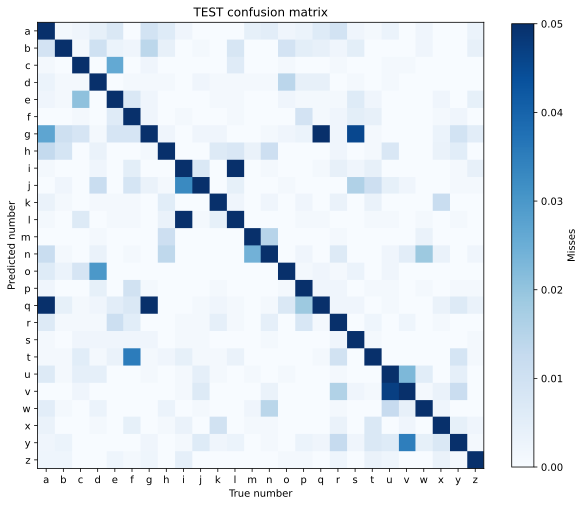

In [48]:
import sklearn.metrics as skm

# compute the confusion matrix
C = skm.confusion_matrix(y.cpu().detach(), torch.argmax(y_hat.cpu().detach(), axis = 1), normalize = 'true')

# visualize it
fig = plt.figure(figsize=(10,10))
plt.imshow(C, 'Blues', vmax = .05)

plt.xticks(range(26), labels = letter_categories)
plt.yticks(range(26), labels = letter_categories)
plt.title('TEST confusion matrix')
plt.xlabel('True number')
plt.ylabel('Predicted number')
plt.colorbar(label = 'Misses', shrink = .8)
plt.show()